# Disease module analysis

Some things to work on
- It seems that the quality of nucleic acid predictions by Pesto is quite poor, looking at many of the proteins it identifies as nucleic acid binders based on UniProt functional annotation they are clearly not nucleic acid binders.
- Improving which proteins we identify in the disease associations.

In [1]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import Optional
import ast
from collections import Counter, defaultdict
import random

pesto_cutoff = 70
plddt_cutoff = 70

## Network construction
Construct 5 networks, one for each modality (protein, lipid, nucleic acid, ligand, and ion) using protein interface similarity defined by InteractNN embeddiings.

In [4]:
with open("/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/case_studies/atomica_net/modality_graphs_20250308.pkl", "rb") as f:
    modality_graphs = pickle.load(f)

In [5]:
def create_similarity_graph(similarity_matrix: np.ndarray, 
                          k: int = 50, 
                          min_similarity: Optional[float] = None) -> nx.Graph:
    """
    Create an undirected graph where each node is connected to its k most similar nodes,
    and all edges have a similarity greater than or equal to min_similarity.
    
    Args:
        similarity_matrix: A square numpy array containing similarity scores
        k: Number of most similar neighbors to connect (default: 50)
        min_similarity: Minimum similarity threshold for edges (default: None)
    
    Returns:
        NetworkX undirected graph
    """
    # Ensure the similarity matrix is square
    n = similarity_matrix.shape[0]
    assert similarity_matrix.shape == (n, n), "Similarity matrix must be square"
    
    # Create empty graph
    G = nx.Graph()
    
    # Add all nodes to the graph
    G.add_nodes_from(range(n))
    
    # For each node, find its k most similar neighbors
    # Use argpartition for efficiency (partial sort)
    for i in range(n):
        # Get similarities for current node
        similarities = similarity_matrix[i]
        
        # We don't want to include the node itself
        similarities[i] = -np.inf
        
        # Get indices of k largest similarities
        top_k_indices = np.argsort(similarities)[::-1][:k]
        
        # Filter by minimum similarity if specified
        if min_similarity is not None:
            top_k_indices = top_k_indices[similarities[top_k_indices] >= min_similarity]
        
        # Add edges
        for j in top_k_indices:
            if G.degree(i) < k and G.degree(j) < k:
                G.add_edge(i, j)
    
    print("Max degree:", max([G.degree(node) for node in G.nodes]))
    
    return G

In [6]:
# cosine similarity cut offs for 90% of the nodes to belong to the giant connected component
embeddings_data_dirs = [
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps_v1/",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps_v2/",
    "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/embeddings_fixed_irreps_v3/",
]

modality_cutoff = {
    "protein": 0.98,
    "lipid": 0.975,
    "nucleic_acid": 0.971,
    "ligand": 0.969,
    "ion": 0.963,
}

modality_graphs = {}

for modality, cutoff in modality_cutoff.items():
    similarity_matrices = []
    uniprot_to_node_idxs = []
    for embeddings_data_dir in embeddings_data_dirs:
        with open(os.path.join(embeddings_data_dir, f"pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl"), "rb") as f:
            embeddings_dataset = pickle.load(f)

        embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
        uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}
        uniprot_to_node_idxs.append(uniprot_to_node_idx)

        similarity_matrix = cosine_similarity(embeddings)
        similarity_matrices.append(similarity_matrix)
    
    assert list(uniprot_to_node_idxs[0].keys()) == list(uniprot_to_node_idxs[1].keys()) == list(uniprot_to_node_idxs[2].keys())
    similarity_matrix = np.mean(similarity_matrices, axis=0)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    print(f"-----------------{modality}-----------------")
    print("Number of embeddings: ", embeddings.shape)
    print("num edges: ", filtered_indices[0].shape[0])

    G = create_similarity_graph(similarity_matrix, k=50, min_similarity=cutoff)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)
    print("size of largest connected component: ", size_of_largest_connected_component)
    print("proportion of largest connected component: ", size_of_largest_connected_component / len(embeddings))
    print("number of connected components", num_connected_components)
    print("density: ", whole_graph_density)
    print("clustering: ", whole_graph_clustering)
    print("average degree: ", np.mean([x[1] for x in G.degree()]))

    largest_component = max(nx.connected_components(G), key=len)
    largest_component_subgraph = G.subgraph(largest_component).copy()
    G = largest_component_subgraph

    adjacency_matrix = similarity_matrix > cutoff
    adjacency_matrix = adjacency_matrix.astype(int)
    largest_component_indices = sorted(list(largest_component))
    largest_component_adj_matrix = adjacency_matrix[np.ix_(largest_component_indices, largest_component_indices)]

    modality_graphs[modality] = {
        "graph": G,
        "uniprot_to_node_idx": uniprot_to_node_idx,
        "largest_component": largest_component,
        "filtered_indices": filtered_indices,
        "adjacency_matrix": largest_component_adj_matrix,
    }

with open("modality_graphs_20250308.pkl", "wb") as f:
    pickle.dump(modality_graphs, f)

-----------------protein-----------------
Number of embeddings:  (17158, 32)
num edges:  5103288
Max degree: 50
size of largest connected component:  15450
proportion of largest connected component:  0.9004545984380464
number of connected components 1597
density:  0.001868375441486635
clustering:  0.25395909039169046
average degree:  32.0557174495862
-----------------lipid-----------------
Number of embeddings:  (6766, 32)
num edges:  188744
Max degree: 50
size of largest connected component:  6055
proportion of largest connected component:  0.8949157552468223
number of connected components 648
density:  0.0037132753022099322
clustering:  0.3139658255150055
average degree:  25.120307419450192
-----------------nucleic_acid-----------------
Number of embeddings:  (6649, 32)
num edges:  661732
Max degree: 50
size of largest connected component:  5974
proportion of largest connected component:  0.898480974582644
number of connected components 606
density:  0.004461552355619648
clustering: 

## Disease Associations

Load all protein-disease associated CSVs.

Disease associations are defined by OpenTargets with a cutoff of their evidence score of > 0.5. This is a rough estimate to define disease associated proteins so not all proteins may seem to be relevant.

In [7]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv", sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

In [8]:
chosen_diseases = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network/open_target_2024_09/chosen_diseases.csv')
disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
disease_associations = disease_associations[disease_associations['diseaseId'].isin(chosen_diseases['diseaseId'])]
disease_id_to_name = dict(zip(disease_associations['diseaseId'], disease_associations['diseaseName']))
disease_name_to_id = dict(zip(disease_associations['diseaseName'], disease_associations['diseaseId']))
print("Number of unique diseases: ", len(disease_associations['diseaseId'].unique()))
disease_associations

Number of unique diseases:  105


,diseaseId,targetId,score,evidenceCount,uniprot_targetId,diseaseName
2754,MONDO_0015760,ENSG00000026103,0.511482,31,P25445,T-cell non-Hodgkin lymphoma
2755,MONDO_0015760,ENSG00000048052,0.520368,257,Q9UKV0,T-cell non-Hodgkin lymphoma
2756,MONDO_0015760,ENSG00000055609,0.507134,13,Q8NEZ4,T-cell non-Hodgkin lymphoma
2757,MONDO_0015760,ENSG00000061273,0.505264,14,Q8WUI4,T-cell non-Hodgkin lymphoma
2758,MONDO_0015760,ENSG00000068024,0.505264,14,P56524,T-cell non-Hodgkin lymphoma
...,...,...,...,...,...,...
182470,EFO_1002049,ENSG00000239732,0.544995,126,Q9NR96,glomerular disease
182471,EFO_1002049,ENSG00000244414,0.587819,67,Q03591,glomerular disease
182869,EFO_1002049,ENSG00000138760,0.695206,118,Q14108,glomerular disease
182870,EFO_1002049,ENSG00000148204,0.821178,73,Q5IJ48,glomerular disease


In [ ]:
with open("chosen_diseases.txt", "r") as f:
    chosen_disease_names = [x.strip() for x in f.readlines()]

print("Num diseases:", len(chosen_disease_names))
for chosen_disease_name in chosen_disease_names:
    print(f'{chosen_disease_name} ({disease_name_to_id[chosen_disease_name]})')

Num diseases: 82
item adrenal gland disease (EFO_0005539)
item Alzheimer disease (MONDO_0004975)
item amyotrophic lateral sclerosis (MONDO_0004976)
item aplastic anemia (MONDO_0015909)
item arterial occlusive disease (EFO_0009085)
item arteriosclerosis (EFO_0009086)
item asthma (MONDO_0004979)
item atherosclerosis (EFO_0003914)
item autism spectrum disorder (EFO_0003756)
item autoimmune neuropathy (MONDO_0000774)
item basal ganglia disease (EFO_0009533)
item bile duct carcinoma (EFO_0005540)
item blood coagulation disease (EFO_0009314)
item blood platelet disease (MONDO_0002245)
item bone marrow cancer (MONDO_0021138)
item breast neoplasm (EFO_0003869)
item cardiac arrhythmia (EFO_0004269)
item cardiomyopathy (EFO_0000318)
item cataract (MONDO_0005129)
item cerebellar ataxia (MONDO_0000437)
item cerebrovascular disorder (EFO_0003763)
item Charcot-Marie-Tooth disease (MONDO_0015626)
item chronic lymphocytic leukemia (EFO_0000095)
item colon carcinoma (EFO_1001950)
item coronary artery d

This loads for each disease the number of proteins associated with it in each network. We want to exclude analysis where there are not enough proteins for that diseases in the network.

In [12]:
modality_disease_counts = pd.read_csv(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/case_studies/atomica_net/modality_chosen_disease_counts_pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_fix_irreps_ensemble.csv")
modality_disease_counts = pd.pivot_table(modality_disease_counts, 
                            values="num_proteins", 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
modalities = ['ion', 'ligand', 'lipid', 'nucleic_acid', 'protein']
modality_disease_counts['is_valid'] = modality_disease_counts.apply(lambda row: sum([1 for x in modalities if row[x] >= 25]) >= 1, axis=1)
modality_disease_counts[modality_disease_counts['is_valid']].sort_values(by='diseaseName').head(50)

,modality,ion,ligand,lipid,nucleic_acid,protein,is_valid
diseaseId,diseaseName,,,,,,
MONDO_0004975,Alzheimer disease,17.0,25.0,27.0,10.0,43.0,True
EFO_1000870,CNS demyelinating autoimmune disease,61.0,25.0,90.0,30.0,103.0,True
MONDO_0015626,Charcot-Marie-Tooth disease,24.0,27.0,17.0,24.0,59.0,True
MONDO_0018772,Joubert syndrome,15.0,13.0,12.0,10.0,37.0,True
MONDO_0009723,Leigh syndrome,9.0,15.0,16.0,4.0,36.0,True
MONDO_0018997,Noonan syndrome,20.0,27.0,5.0,14.0,31.0,True
MONDO_0005180,Parkinson disease,27.0,31.0,53.0,21.0,73.0,True
Orphanet_98693,Spinocerebellar ataxia with oculomotor anomaly,22.0,16.0,11.0,15.0,30.0,True
MONDO_0024615,T-cell and NK-cell neoplasm,19.0,22.0,5.0,16.0,28.0,True


In [ ]:
# cross_validation_assignments = {}
# for seed in range(100):
#     np.random.seed(seed)
#     for disease in chosen_diseases['diseaseId'].unique():
#         disease_proteins = disease_associations[disease_associations['diseaseId'] == disease]['uniprot_targetId'].unique()
#         disease_proteins = np.random.permutation(disease_proteins)
#         num_folds = 5
#         folds = np.array_split(disease_proteins, num_folds)
#         for i in range(num_folds):
#             train_proteins = np.concatenate([folds[j] for j in range(num_folds) if j != i])
#             test_proteins = folds[i]

#             cross_validation_assignments[(disease, i)] = {
#                 "train_proteins": train_proteins,
#                 "test_proteins": test_proteins,
#             }
#     with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/cv_splits_fix_irreps_ensemble/cv_split_{seed}.pkl", "wb") as f:
#         pickle.dump(cross_validation_assignments, f)

In [11]:
# def get_associated_diseases(uniprot_id):
#     diseases = disease_associations[(disease_associations['uniprot_targetId'] == uniprot_id) & (disease_associations['diseaseName'].isin(chosen_disease_names))]['diseaseId'].values.tolist()
#     return diseases

# for modality in modality_graphs:
#     G = modality_graphs[modality]['graph']
#     uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
#     node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}

#     output_path = f"/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/case_studies/network_analysis/graphs/ATOMICANet_{modality}.gml"
#     for node in G.nodes():
#         uniprot_id = node_idx_to_uniprot[node]
#         G.nodes[node]['protein_name'] = uniprot_id
#         G.nodes[node]['gene'] = uniprot_to_gene.get(uniprot_id, "")
#         G.nodes[node]['gene'] = "" if pd.isna(G.nodes[node]['gene']) else G.nodes[node]['gene']
#         G.nodes[node]['diseases'] = ", ".join([disease_id_to_name[x] for x in get_associated_diseases(uniprot_id)])
#     nx.write_gml(G, output_path)

## Disease connectivity

In [13]:
def get_disease_connectivity(modality, disease_id):
    G = modality_graphs[modality]['graph'].copy()
    uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    largest_component = modality_graphs[modality]['largest_component']

    filtered_relations_df = disease_associations[disease_associations['diseaseId'] == disease_id].copy()
    number_of_disease_proteins = len(filtered_relations_df['uniprot_targetId'].unique())
    filtered_relations_df['node_idx'] = filtered_relations_df['uniprot_targetId'].map(uniprot_to_node_idx).fillna(-1).astype(int)
    filtered_relations_df = filtered_relations_df[(filtered_relations_df['node_idx'] != -1) & (filtered_relations_df['node_idx'].isin(largest_component))].copy()
    selected_disease_nodes = filtered_relations_df['node_idx'].tolist()

    if len(selected_disease_nodes) == 0:
        return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": 0, 
                "number_of_nodes": 0, "size_of_largest_pathway_component": 0, "num_components": 0, 
                "density": 0, "clustering": 0, "proteins_in_largest_component": []}

    subgraph = G.subgraph(selected_disease_nodes)

    components = sorted(nx.connected_components(subgraph), key=len, reverse=True)

    largest_component = components[0]
    size_of_largest_component = len(largest_component)

    subgraph_num_components = nx.number_connected_components(subgraph)
    subgraph_density = nx.density(subgraph)
    subgraph_clustering = nx.average_clustering(subgraph)
    number_of_nodes = len(selected_disease_nodes)
    proteins = [node_idx_to_uniprot[x] for x in largest_component]
    all_proteins = [node_idx_to_uniprot[x] for x in selected_disease_nodes]
    
    return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": size_of_largest_component, 
            "number_of_nodes": number_of_nodes, "relative_size_of_largest_pathway_component": size_of_largest_component/number_of_nodes, 
            "relative_size_of_number_of_nodes": number_of_nodes/number_of_disease_proteins,
            "num_components": subgraph_num_components, "density": subgraph_density, "clustering": subgraph_clustering,
            "proteins_in_largest_component": proteins, 'all_proteins': all_proteins, 'components': components}


disease_connectivity = []
for disease_id in tqdm(disease_associations['diseaseId'].unique(), total=len(disease_associations['diseaseId'].unique())):
    for modality in modality_graphs:
        disease_connectivity.append(get_disease_connectivity(modality, disease_id))

disease_connectivity_df = pd.DataFrame(disease_connectivity)
disease_connectivity_df['diseaseName'] = disease_connectivity_df['diseaseId'].map(disease_id_to_name)
disease_connectivity_df[disease_connectivity_df['number_of_nodes']>=25].sort_values('num_components', ascending=True)

100%|██████████| 105/105 [02:26<00:00,  1.39s/it]


,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,all_proteins,components,diseaseName
336,lipid,MONDO_0000774,31,43,0.720930,0.977273,9,0.109635,0.412925,"[Q14721, Q9ULD8, O43525, P22001, Q9NSA2, Q8TDN...","[Q9UIX4, P51787, Q12809, O43526, P22303, Q9UQ0...","[{6151, 1934, 4111, 536, 2461, 1316, 1192, 427...",autoimmune neuropathy
339,ion,MONDO_0000774,9,39,0.230769,0.886364,15,0.052632,0.244444,"[Q09470, Q9NR82, P16389, Q9NS40, Q9UQ05, P2245...","[Q9UIX4, P51787, O43526, Q9UQ05, Q9NSA2, Q96RP...","[{3972, 4358, 3975, 1265, 5655, 1400, 187, 642...",autoimmune neuropathy
156,lipid,MONDO_0004975,9,27,0.333333,0.500000,18,0.028490,0.061728,"[Q14957, Q12879, P04035, P12821, Q8TCU5, Q0558...","[Q30201, Q9UKA4, Q8WTV0, P35354, P49768, P2230...","[{5796, 6183, 4332, 5932, 4047, 6097, 4882, 25...",Alzheimer disease
248,ligand,MONDO_0018997,4,27,0.148148,0.574468,18,0.028490,0.086420,"[P61224, P62070, Q92963, P62834]","[P27448, P60709, P10398, Q8N653, P28482, P2736...","[{2888, 3891, 4925, 4623}, {5833, 3426, 3297, ...",Noonan syndrome
274,ion,EFO_0004251,5,25,0.200000,0.462963,19,0.020000,0.000000,"[P12931, P08631, P06241, P07948, O96017]","[P09769, P06241, O60674, P08631, P52333, Q1591...","[{6441, 4300, 6395, 476, 5597}, {6113, 6391}, ...",myeloproliferative disorder
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,protein,EFO_0000474,8,220,0.036364,0.823970,150,0.003196,0.058333,"[Q01118, Q9H3T3, O15399, Q99250, Q14683, Q1279...","[Q96QS3, P35499, Q9NY47, Q9BRB3, P17600, O7603...","[{16609, 2050, 14051, 11496, 16302, 12754, 154...",epilepsy
171,lipid,OTAR_0000020,290,634,0.457413,0.417655,161,0.005910,0.235573,"[Q9Y5Y5, P31645, Q9NQ11, P14672, Q14721, Q1325...","[O60762, Q9UJS0, P30988, P21439, P13473, Q0942...","[{6656, 4099, 6147, 6659, 6151, 6152, 4107, 61...",nutritional or metabolic disease
55,protein,EFO_0000574,5,204,0.024510,0.689189,161,0.002173,0.026144,"[Q01118, Q99250, O14497, P46527, Q9Y5Y9]","[Q92851, P40259, P35499, P20273, Q14181, P2544...","[{16609, 11496, 13704, 13329, 15415}, {11585, ...",lymphoma
390,protein,EFO_0003869,32,345,0.092754,0.815603,215,0.002376,0.037488,"[Q13206, Q06609, O14497, Q93074, Q8TCU5, P4652...","[O14561, P40259, P35499, P34903, P38398, Q1418...","[{14849, 16001, 13704, 11788, 10636, 13329, 13...",breast neoplasm


## P value test on disease associations

In [ ]:
p_val = []
for index, row in tqdm(modality_disease_counts.iterrows(), total=len(modality_disease_counts)):
    disease_id = index[0]
    disease_name = index[1]
    for modality in modality_graphs:
        G = modality_graphs[modality]['graph']
        num_disease_nodes = int(row[modality])
        if num_disease_nodes < 25:
            continue

        num_components = disease_connectivity_df[(disease_connectivity_df['diseaseId'] == disease_id) & (disease_connectivity_df['modality'] == modality)]['num_components'].values[0]
        size_of_largest_connected_component = disease_connectivity_df[(disease_connectivity_df['diseaseId'] == disease_id) & (disease_connectivity_df['modality'] == modality)]['size_of_largest_connected_component'].values[0]

        null_model_num_components = []
        null_model_size_of_largest_connected_component = []
        for i in range(1000):
            np.random.seed(i)
            rand_nodes = np.random.choice(list(G.nodes), num_disease_nodes, replace=False)
            rand_subgraph = G.subgraph(rand_nodes)
            rand_num_components = nx.number_connected_components(rand_subgraph)
            rand_size_of_largest_connected_component = max([len(x) for x in nx.connected_components(rand_subgraph)])
            null_model_num_components.append(rand_num_components)
            null_model_size_of_largest_connected_component.append(rand_size_of_largest_connected_component)
        p_val.append({
            "diseaseId": disease_id,
            "diseaseName": disease_name,
            "modality": modality,
            "p_val_num_components": sum([1 for x in null_model_num_components if x <= num_components]) / len(null_model_num_components),
            "p_val_size_of_largest_connected_component": sum([1 for x in null_model_size_of_largest_connected_component if x >= size_of_largest_connected_component]) / len(null_model_size_of_largest_connected_component),
        })
p_val = pd.DataFrame(p_val)
p_val.to_csv(f"p_val_random_subnetworks.csv", index=False)

100%|██████████| 105/105 [14:49<00:00,  8.47s/it]


In [ ]:
p_val = []

degree_to_nodes_modality = {}
for modality in modality_graphs:
    G = modality_graphs[modality]['graph']
    degree_to_nodes = defaultdict(set)
    for node in G.nodes():
        deg = G.degree(node)
        degree_to_nodes[deg].add(node)
    degree_to_nodes_modality[modality] = degree_to_nodes

for index, row in tqdm(modality_disease_counts.iterrows(), total=len(modality_disease_counts)):
    disease_id = index[0]
    disease_name = index[1]
    for modality in modality_graphs:
        G = modality_graphs[modality]['graph']
        uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
        largest_component = modality_graphs[modality]['largest_component']
        num_disease_nodes = int(row[modality])
        if num_disease_nodes < 25:
            continue

        num_components = disease_connectivity_df[(disease_connectivity_df['diseaseId'] == disease_id) & (disease_connectivity_df['modality'] == modality)]['num_components'].values[0]
        size_of_largest_connected_component = disease_connectivity_df[(disease_connectivity_df['diseaseId'] == disease_id) & (disease_connectivity_df['modality'] == modality)]['size_of_largest_connected_component'].values[0]

        disease_proteins = disease_associations[disease_associations['diseaseId'] == disease_id]['uniprot_targetId'].unique()
        disease_nodes = [uniprot_to_node_idx[x] for x in disease_proteins if x in uniprot_to_node_idx and uniprot_to_node_idx[x] in largest_component]
        original_degrees = [G.degree(n) for n in disease_nodes]

        all_samples = []
        for _ in range(1000):
            sampled_nodes = set()
            for deg in original_degrees:
                if deg in degree_to_nodes and degree_to_nodes[deg]:
                    # Sample without replacement
                    available_nodes = degree_to_nodes[deg] - sampled_nodes
                    if not available_nodes:
                        print(f"Warning: Could not find matching node for degree {deg}")
                        break
                    node = random.choice(list(available_nodes))
                    sampled_nodes.add(node)
                else:
                    print(f"Warning: Could not find matching node for degree {deg}")
                    break
            if len(sampled_nodes) == len(disease_nodes):
                all_samples.append(tuple(sorted(sampled_nodes)))
        
        if len(all_samples) == 0:
            print(f"Warning: Could not find matching nodes for disease {disease_id}")
            p_val.append({
                "diseaseId": disease_id,
                "diseaseName": disease_name,
                "modality": modality,
                "p_val_num_components": pd.NA,
                "p_val_size_of_largest_connected_component": pd.NA,
                "num_samples": 0,
            })
            continue
        
        all_samples = list(set(all_samples))
        null_model_num_components = []
        null_model_size_of_largest_connected_component = []
        for rand_nodes in all_samples:
            np.random.seed(i)
            rand_subgraph = G.subgraph(rand_nodes)
            rand_num_components = nx.number_connected_components(rand_subgraph)
            rand_size_of_largest_connected_component = max([len(x) for x in nx.connected_components(rand_subgraph)])
            null_model_num_components.append(rand_num_components)
            null_model_size_of_largest_connected_component.append(rand_size_of_largest_connected_component)
        p_val.append({
            "diseaseId": disease_id,
            "diseaseName": disease_name,
            "modality": modality,
            "p_val_num_components": sum([1 for x in null_model_num_components if x <= num_components]) / len(null_model_num_components),
            "p_val_size_of_largest_connected_component": sum([1 for x in null_model_size_of_largest_connected_component if x >= size_of_largest_connected_component]) / len(null_model_size_of_largest_connected_component),
            "num_samples": len(all_samples),
        })
p_val = pd.DataFrame(p_val)
p_val.to_csv(f"p_val_random_subnetworks_same_degree.csv", index=False)

  0%|          | 0/105 [00:00<?, ?it/s]

100%|██████████| 105/105 [14:26<00:00,  8.25s/it]


In [ ]:
from statsmodels.stats.multitest import fdrcorrection
from statsmodels.stats.multitest import multipletests

p_val = pd.read_csv("p_val_random_subnetworks_same_degree.csv")
p_val = p_val[p_val['diseaseName'].isin(chosen_disease_names)]

chosen_modality = 'ion'
p_val_modality = p_val[p_val['modality'] == chosen_modality].copy()
print("Num hypotheses: ", len(p_val_modality))
rejected, corrected_p_vals, _, _ = multipletests(p_val_modality['p_val_size_of_largest_connected_component'], alpha=0.05, method='fdr_bh')

p_val_modality['rejected_lcc'] = rejected
p_val_modality['corrected_p_val_lcc'] = corrected_p_vals
rejected, corrected_p_vals = fdrcorrection(p_val_modality['p_val_num_components'], alpha=0.05)
p_val_modality['rejected_num_components'] = rejected
p_val_modality['corrected_p_val_num_components'] = corrected_p_vals
print(f"Num rejected: based on size of LCC {sum(p_val_modality['rejected_lcc'])}, based on number of components {sum(p_val_modality['rejected_num_components'])}")
p_val_modality[p_val_modality['rejected_lcc'] | p_val_modality['rejected_num_components']]

Num hypotheses:  35
Num rejected: based on size of LCC 10, based on number of components 11


,diseaseId,diseaseName,modality,p_val_num_components,p_val_size_of_largest_connected_component,num_samples,rejected_lcc,corrected_p_val_lcc,rejected_num_components,corrected_p_val_num_components
24,EFO_0000400,diabetes mellitus,ion,0.000,0.001,1000,True,0.007000,True,0.000000
29,EFO_0000474,epilepsy,ion,0.001,0.002,1000,True,0.010000,True,0.003889
33,EFO_0000538,hypertrophic cardiomyopathy,ion,0.005,0.162,1000,False,0.436154,True,0.017500
39,EFO_0000574,lymphoma,ion,0.006,0.014,1000,True,0.049000,True,0.019091
56,EFO_0001645,coronary artery disease,ion,0.000,0.009,1000,True,0.035000,True,0.000000
76,EFO_0003763,cerebrovascular disorder,ion,0.000,0.009,1000,True,0.035000,True,0.000000
98,EFO_0004251,myeloproliferative disorder,ion,0.000,0.002,1000,True,0.010000,True,0.000000
147,MONDO_0000774,autoimmune neuropathy,ion,0.000,0.000,1000,True,0.000000,True,0.000000
182,MONDO_0004643,myeloid leukemia,ion,0.000,0.000,1000,True,0.000000,True,0.000000
218,MONDO_0005301,multiple sclerosis,ion,0.000,0.000,1000,True,0.000000,True,0.000000


In [ ]:
significant_diseases = []
for chosen_modality in modalities:
    p_val_modality = p_val[p_val['modality'] == chosen_modality].copy()
    # print("Num hypotheses: ", len(p_val_modality))
    rejected, corrected_p_vals, _, _ = multipletests(p_val_modality['p_val_size_of_largest_connected_component'], alpha=0.05, method='fdr_bh')
    p_val_modality['rejected_lcc'] = rejected
    p_val_modality['corrected_p_val_lcc'] = corrected_p_vals
    rejected, corrected_p_vals = fdrcorrection(p_val_modality['p_val_num_components'], alpha=0.05)
    p_val_modality['rejected_num_components'] = rejected
    p_val_modality['corrected_p_val_num_components'] = corrected_p_vals
    # print(f"Num rejected: based on size of LCC {sum(p_val_modality['rejected_lcc'])}, based on number of components {sum(p_val_modality['rejected_num_components'])}")
    diseases = p_val_modality[p_val_modality['rejected_lcc'] | p_val_modality['rejected_num_components']]['diseaseId'].unique()
    disease_names = [disease_id_to_name[x] for x in diseases]
    significant_diseases_modality = {
        "modality": chosen_modality,
        "diseaseId": diseases,
        "diseaseName": disease_names,
    }
    significant_diseases_modality_df = pd.DataFrame(significant_diseases_modality)
    significant_diseases.append(significant_diseases_modality_df)
significant_diseases = pd.concat(significant_diseases)
significant_diseases

,modality,diseaseId,diseaseName
0,ion,EFO_0000400,diabetes mellitus
1,ion,EFO_0000474,epilepsy
2,ion,EFO_0000538,hypertrophic cardiomyopathy
3,ion,EFO_0000574,lymphoma
4,ion,EFO_0001645,coronary artery disease
5,ion,EFO_0003763,cerebrovascular disorder
6,ion,EFO_0004251,myeloproliferative disorder
7,ion,MONDO_0000774,autoimmune neuropathy
8,ion,MONDO_0004643,myeloid leukemia
9,ion,MONDO_0005301,multiple sclerosis


## How connected are disease associated proteins across the 5 networks?

In [42]:
from statsmodels.stats.multitest import fdrcorrection

In [156]:
test_name = "edge_permutation_test"
disease_connectivity = []
dirname = f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/{test_name}/"
for fname in os.listdir(dirname):
    df = pd.read_csv(os.path.join(dirname, fname))
    disease_connectivity.append(df)
disease_connectivity = pd.concat(disease_connectivity)
disease_connectivity['proteins_in_largest_component'] = disease_connectivity['proteins_in_largest_component'].apply(ast.literal_eval)

In [157]:
disease_connectivity

,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,seed,diseaseName
0,protein,MONDO_0015909,3,50,0.060000,0.781250,45,0.004082,0.00000,"[P62273, P37287, P23458]",-1,aplastic anemia
1,nucleic_acid,MONDO_0015909,5,37,0.135135,0.578125,31,0.009009,0.00000,"[P62847, P62854, P01024, P61254, Q8IY92]",-1,aplastic anemia
2,ion,MONDO_0015909,2,26,0.076923,0.406250,24,0.006154,0.00000,"[O43903, Q5T890]",-1,aplastic anemia
3,protein,MONDO_0015909,3,50,0.060000,0.781250,46,0.003265,0.00000,"[Q8NB91, P32969, O76094]",0,aplastic anemia
4,nucleic_acid,MONDO_0015909,2,37,0.054054,0.578125,36,0.001502,0.00000,"[Q9NPI8, Q07020]",0,aplastic anemia
...,...,...,...,...,...,...,...,...,...,...,...,...
3999,ion,EFO_0004269,1,25,0.040000,0.238095,25,0.000000,0.00000,[Q9UI33],998,cardiac arrhythmia
4000,protein,EFO_0004269,4,78,0.051282,0.742857,69,0.002997,0.00000,"[P35499, Q12809, P11229, Q01668]",999,cardiac arrhythmia
4001,lipid,EFO_0004269,22,83,0.265060,0.790476,55,0.009110,0.01004,"[P35348, Q01118, P35499, Q9Y5Y9, Q9Y3Q4, P2822...",999,cardiac arrhythmia
4002,nucleic_acid,EFO_0004269,2,25,0.080000,0.238095,23,0.006667,0.00000,"[P35499, Q14524]",999,cardiac arrhythmia


In [158]:
disease_connectivity_permuted = disease_connectivity[disease_connectivity['seed'] > 0]
disease_connectivity_permuted = disease_connectivity_permuted.groupby(['diseaseId', 'diseaseName', 'modality']).agg({
    'size_of_largest_connected_component': lambda x: sorted(list(x)),
    'relative_size_of_largest_pathway_component': lambda x: sorted(list(x)),
    'proteins_in_largest_component': list,
    'num_components': lambda x: sorted(list(x)),
})
disease_connectivity_permuted['proteins_in_largest_component'] = disease_connectivity_permuted['proteins_in_largest_component'].apply(lambda x: Counter([item for sublist in x for item in sublist]))
disease_connectivity_permuted.reset_index(inplace=True)

In [159]:
p_vals = []
for feature in ['size_of_largest_connected_component', 'relative_size_of_largest_pathway_component', 'num_components']:
    for disease in disease_connectivity['diseaseName'].unique():
        for modality in disease_connectivity['modality'].unique():
            filtered_df =  disease_connectivity[(disease_connectivity['diseaseName'] == disease) & (disease_connectivity['modality'] == modality) & (disease_connectivity['seed'] == -1)]
            if len(filtered_df) == 0:
                continue
            test_val = filtered_df[feature].values[0]
            dist = disease_connectivity_permuted[(disease_connectivity_permuted['diseaseName'] == disease) & (disease_connectivity_permuted['modality'] == modality)][feature].values[0]
            if feature == 'num_components':
                p_val = (np.sum([1 for x in dist if x <= test_val]) + 1) / (len(dist) + 1)
            else:
                p_val = (np.sum([1 for x in dist if x >= test_val]) + 1) / (len(dist) + 1)
            p_vals.append({
                'diseaseName': disease,
                'modality': modality,
                'feature': feature,
                'p_val': p_val,
            })
p_vals = pd.DataFrame(p_vals)

In [160]:
p_vals_pivot = p_vals.pivot_table(index=['diseaseName', 'modality'], columns='feature', values='p_val', aggfunc='mean').reset_index()
p_vals_pivot.to_csv(f"p_vals_{test_name}.csv", index=False)

In [163]:
p_vals_pivot = pd.read_csv("p_vals_edge_permutation_test.csv")
modality = 'ligand'
print(f"Num hypotheses: {len(p_vals_pivot[p_vals_pivot['modality'] == modality])}")
rejected, corrected_p_vals, _, _ = multipletests(p_vals_pivot[p_vals_pivot['modality'] == modality]['num_components'], alpha=0.05, method='fdr_bh')
corrected_p_vals_df = {
    "p_vals": p_vals_pivot[p_vals_pivot['modality'] == modality]['diseaseName'],
    "rejected": rejected,
    "corrected_p_vals": corrected_p_vals,
}
corrected_p_vals_df = pd.DataFrame(corrected_p_vals_df).sort_values('corrected_p_vals')
corrected_p_vals_df

Num hypotheses: 46


,p_vals,rejected,corrected_p_vals
12,Noonan syndrome,False,0.667000
83,colorectal adenocarcinoma,False,0.667000
146,hypertrophic cardiomyopathy,False,0.667000
235,prostate carcinoma,False,0.667000
87,colorectal neoplasm,False,0.681375
129,head and neck neoplasia,False,0.681375
110,ectodermal dysplasia syndrome,False,0.681375
45,blood coagulation disease,False,0.681375
133,head and neck squamous cell carcinoma,False,0.681375
119,esophageal disease,False,0.681375


# Sizes of connected components

In [15]:
disease_connectivity_df.groupby('modality').agg({
    'relative_size_of_largest_pathway_component': ['mean', 'std'],
    'num_components': ['mean', 'std'],
    'size_of_largest_connected_component': ['mean', 'std'],
})

relative_size_of_largest_pathway_component            \
                                                   mean       std   
modality                                                            
ion                                            0.110601  0.087362   
ligand                                         0.106195  0.086565   
lipid                                          0.164637  0.125805   
nucleic_acid                                   0.099468  0.051078   
protein                                        0.060684  0.048818   

             num_components            size_of_largest_connected_component  \
                       mean        std                                mean   
modality                                                                     
ion               24.209524  17.917383                            6.019048   
ligand            24.971429  18.213191                            7.342857   
lipid             25.685714  21.736319                            8.933333   
nucleic_acid      23.714286  19.723431                            3.380952   
protein           55.219048  41.642245                            8.257143   

                         
                    std  
modality                 
ion           33.525530  
ligand        48.120807  
lipid         29.451481  
nucleic_acid  12.745573  
protein       51.709438

Number of diseases with sufficient data in at least two modalities: 27 out of 103


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/tmp/ipykernel_208088/3820794335.py:52: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


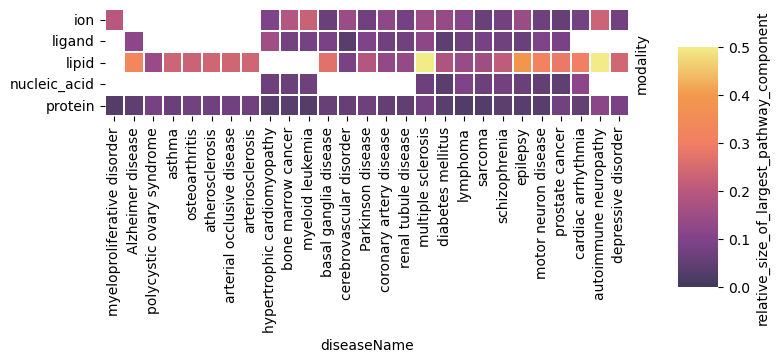

In [43]:
from matplotlib.colors import LinearSegmentedColormap

colors = ['#423B5C', '#82438B', '#B9587E', '#F27E63', '#F2994B', '#F2EB88']
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

chosen_metric = 'relative_size_of_largest_pathway_component'
pivoted_df = pd.pivot_table(disease_connectivity_df[(disease_connectivity_df['number_of_nodes'] > 1)], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')
pivoted_df = pivoted_df[~pivoted_df['diseaseName'].isin(['nutritional or metabolic disease', 'thyroid carcinoma'])]

# remove the diseases with less than 25 proteins
min_modality_protein_count = 25
for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
    pivoted_df[modality] = pivoted_df.apply(lambda row: row[modality] if modality_disease_counts.loc[(row['diseaseId'], row['diseaseName'])][modality] >= min_modality_protein_count else -1, axis=1)

pivoted_df['sufficient_data'] = pivoted_df['diseaseId'].isin(significant_diseases['diseaseId'])
# pivoted_df['sufficient_data'] = pivoted_df.apply(lambda row: sum([1 for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid'] if row[modality] != -1]) > 1, axis=1)
print(f"Number of diseases with sufficient data in at least two modalities: {sum(pivoted_df['sufficient_data'])} out of {len(pivoted_df)}")
pivoted_df = pivoted_df[pivoted_df['sufficient_data']]
pivoted_df = pivoted_df.drop('sufficient_data', axis=1)

# fig, ax = plt.subplots(figsize=(6, 8))
plotting_df = pivoted_df.set_index('diseaseName').drop('diseaseId', axis=1)
mask = plotting_df==-1

# plot all modalities in the same color
ax = sns.clustermap(
    plotting_df.T,
    cmap=custom_cmap,  # Use the same colormap
    mask=mask.T,                                       # Mask to hide certain cells
    cbar_kws={"label": chosen_metric, "location": "right"},             # Colorbar settings, replace 'Chosen Metric' with your variable
    cbar_pos=(0.9, 0.2, 0.05, 0.6),
    vmin=0,                                          # Set the minimum value for the colormap
    vmax=0.5,                                        # Set the maximum value for the colormap
    method='average',                                # Method for hierarchical clustering (default is 'average')
    metric='euclidean',                              # Distance metric for clustering (default is 'euclidean')
    square=True,
    linewidths=0.2,
    linecolor='white',
    figsize=(8,4),                                  # Figure size, adjust as needed
    row_cluster=False,                               # Turn off column clustering
    fmt='',
)
ax.ax_row_dendrogram.set_visible(False)  # Hide the row dendrogram
ax.ax_col_dendrogram.set_visible(False)  # Hide the column dendrogram
ax.ax_heatmap.yaxis.tick_left() 
plt.tight_layout()
plt.savefig(f"visualisation/{chosen_metric}_heatmap.svg", format='svg', bbox_inches='tight')

In [24]:
chosen_disease = 'autoimmune neuropathy'
chosen_modality = 'ion'

largest_component_disease_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['proteins_in_largest_component'].values[0]
disease_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['all_proteins'].values[0]
print("number of disease proteins in largest component", len(largest_component_disease_proteins))
print("disease proteins in largest component", " ".join(largest_component_disease_proteins))
print("number of disease proteins", len(disease_proteins))
print("disease proteins", " ".join(disease_proteins))

number of disease proteins in largest component 9
disease proteins in largest component Q09470 Q9NR82 P16389 Q9NS40 Q9UQ05 P22459 Q9H252 P22460 O43526
number of disease proteins 39
disease proteins Q9UIX4 P51787 O43526 Q9UQ05 Q9NSA2 Q96RP8 Q09470 Q03721 P56696 Q96KK3 P48547 P22460 Q14003 Q9ULD8 Q8NCM2 Q16322 O95259 P17658 Q9ULS6 Q14721 Q9H3M0 Q6PIU1 Q96PR1 Q8TDN2 Q8TDN1 Q9BQ31 Q9UK17 Q9H252 P22001 P16389 P22459 Q92953 Q96L42 O43525 Q9NZV8 Q9NS40 Q9NR82 Q8TAE7 Q9UJ96


In [25]:
chosen_disease_components = []
components = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['components'].iloc[0]
for component_idx, component in enumerate(components):
    uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    for node in component:
        chosen_disease_components.append([component_idx, node, node_idx_to_uniprot[node]])
chosen_disease_components_df = pd.DataFrame(chosen_disease_components, columns=['component_idx', 'node', 'uniprot'])
chosen_disease_components_df['gene'] = chosen_disease_components_df['uniprot'].map(uniprot_to_gene)
chosen_disease_components_df['protein_name'] = chosen_disease_components_df['uniprot'].map(uniprot_to_protein_name)
chosen_disease_components_df['evidence_score'] = chosen_disease_components_df['uniprot'].map(lambda x: disease_associations[(disease_associations['uniprot_targetId'] == x) & (disease_associations['diseaseName'] == chosen_disease)]['score'].values[0])
chosen_disease_components_df['evidence_count'] = chosen_disease_components_df['uniprot'].map(lambda x: disease_associations[(disease_associations['uniprot_targetId'] == x) & (disease_associations['diseaseName'] == chosen_disease)]['evidenceCount'].values[0])
print(chosen_disease_components_df.groupby('component_idx').agg({'evidence_score': ['mean', 'std', 'count'], 'evidence_count': ['mean', 'std', 'count']}).head(5))

chosen_disease_components_df.sort_values(by=['component_idx', 'evidence_score'], ascending=[True, False]).head(50)

              evidence_score                 evidence_count                
                        mean       std count           mean       std count
component_idx                                                              
0                   0.573774  0.002889     9           13.0  2.645751     9
1                   0.572488  0.000000     6           12.0  0.000000     6
2                   0.572488  0.000000     5           12.0  0.000000     5
3                   0.572488  0.000000     4           12.0  0.000000     4
4                   0.572488  0.000000     3           12.0  0.000000     3


,component_idx,node,uniprot,gene,protein_name,evidence_score,evidence_count
0,0,3972,Q09470,KCNA1,Potassium voltage-gated channel subfamily A me...,0.580984,13
5,0,1400,P22459,KCNA4 KCNA4L,Potassium voltage-gated channel subfamily A me...,0.575565,20
1,0,4358,Q9NR82,KCNQ5,Potassium voltage-gated channel subfamily KQT ...,0.572488,12
2,0,3975,P16389,KCNA2,Potassium voltage-gated channel subfamily A me...,0.572488,12
3,0,1265,Q9NS40,KCNH7 ERG3,Voltage-gated inwardly rectifying potassium ch...,0.572488,12
4,0,5655,Q9UQ05,KCNH4,Voltage-gated delayed rectifier potassium chan...,0.572488,12
6,0,187,Q9H252,KCNH6 ERG2,Voltage-gated inwardly rectifying potassium ch...,0.572488,12
7,0,6429,P22460,KCNA5,Potassium voltage-gated channel subfamily A me...,0.572488,12
8,0,4767,O43526,KCNQ2,Potassium voltage-gated channel subfamily KQT ...,0.572488,12
9,1,6309,O95259,KCNH1 EAG EAG1,Voltage-gated delayed rectifier potassium chan...,0.572488,12


In [26]:
# write out the graph for visualization
uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
G = modality_graphs[chosen_modality]['graph'].copy()
for node in G.nodes():
    uniprot_id = node_idx_to_uniprot[node]
    G.nodes[node]['protein_name'] = uniprot_id
    G.nodes[node]['gene'] = uniprot_to_gene.get(uniprot_id, "")
    G.nodes[node]['gene'] = "" if pd.isna(G.nodes[node]['gene']) else G.nodes[node]['gene'].split(" ")[0]
    G.nodes[node]['degree'] = G.degree(node)
    if uniprot_id in chosen_disease_components_df['uniprot'].values:
        G.nodes[node][chosen_disease] = True
        G.nodes[node]['evidence_score'] = chosen_disease_components_df[chosen_disease_components_df['uniprot'] == uniprot_id]['evidence_score'].values[0]
        G.nodes[node]['evidence_count'] = chosen_disease_components_df[chosen_disease_components_df['uniprot'] == uniprot_id]['evidence_count'].values[0]
        G.nodes[node]['component_idx'] = chosen_disease_components_df[chosen_disease_components_df['uniprot'] == uniprot_id]['component_idx'].values[0]
    else:
        G.nodes[node][chosen_disease] = False
        G.nodes[node]['evidence_score'] = 0.0
        G.nodes[node]['evidence_count'] = 0
        G.nodes[node]['component_idx'] = -1

# Find disease nodes
disease_nodes = [node for node in G.nodes() if G.nodes[node][chosen_disease]]
nodes_to_keep = set(disease_nodes)
for node in G.nodes():
    if node not in disease_nodes:  # only check non-disease nodes
        disease_neighbors = sum(1 for neighbor in G.neighbors(node) if neighbor in disease_nodes)
        if disease_neighbors >= 2:  # keep if connected to 2+ disease nodes
            nodes_to_keep.add(node)

# Remove nodes that aren't in nodes_to_keep
nodes_to_remove = [node for node in G.nodes() if node not in nodes_to_keep]
G.remove_nodes_from(nodes_to_remove)

nx.write_gexf(G, f"visualisation/{chosen_disease.replace(' ', '_')}_{chosen_modality}.gexf")

In [29]:
component_0_count = 0
for node in G.nodes():
    if G.nodes[node]['component_idx'] == 0 and G.nodes[node][chosen_disease]:
        component_0_count += 1
print(component_0_count)

12


In [60]:
chosen_metric = 'size_of_largest_connected_component'
pivoted_df = pd.pivot_table(disease_connectivity_df[disease_connectivity_df['number_of_nodes'] > 1], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')
pivoted_df.sort_values('ligand', ascending=False).head(20)

modality,diseaseId,diseaseName,ion,ligand,lipid,nucleic_acid,protein
102,OTAR_0000020,nutritional or metabolic disease,275.0,477.0,176.0,54.0,482.0
12,EFO_0000574,lymphoma,8.0,15.0,9.0,7.0,7.0
30,EFO_0003869,breast neoplasm,10.0,10.0,11.0,7.0,71.0
68,MONDO_0004736,inborn disorder of amino acid metabolism,7.0,10.0,3.0,3.0,45.0
6,EFO_0000318,cardiomyopathy,4.0,8.0,2.0,2.0,4.0
9,EFO_0000474,epilepsy,11.0,8.0,20.0,5.0,39.0
39,EFO_0005950,head and neck neoplasia,4.0,7.0,9.0,3.0,4.0
53,MONDO_0000437,cerebellar ataxia,3.0,7.0,3.0,3.0,5.0
33,EFO_0004142,colorectal neoplasm,3.0,6.0,3.0,4.0,11.0
25,EFO_0003060,non-small cell lung carcinoma,2.0,5.0,3.0,3.0,2.0


## Disease module detection algorithms

We run three disease module detection algorithms on the 5 networks (random walk, neighborhood, and DIAMOnD). For a given disease we run a 5 fold cross validation where we select one fold (20%) of disease-associated proteins to be test proteins and the remaining 80% to be seed proteins. We then run the disease module detection algorithm and evaluate proteins detected in the top 500 nominated proteins. This is repeated 64 times for each disease.


Random Walk performs the best.

In [51]:
from glob import glob
num_completed = len(glob("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_*_fix_irreps_ensemble.pkl"))
num_completed

100

In [52]:
import pandas as pd
import pickle 
import os

results_df = pd.DataFrame()
for i in range(100):
    fname = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_{i}_fix_irreps_ensemble.pkl"
    if not os.path.exists(fname):
        print(f"{i} does not exist")
        continue
    with open(fname, "rb") as f:
        results = pickle.load(f)
        results_df = pd.concat([results_df, results])

In [179]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_fix_irreps_ensemble.pkl", "wb") as f:
    pickle.dump(results_df, f)

In [7]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_fix_irreps_ensemble.pkl", "rb") as f:
    results_df = pickle.load(f)

In [53]:
num_found_per_disease = []
for disease in tqdm(results_df['diseaseName'].unique(), total=len(results_df['diseaseName'].unique())):
    for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
        found_proteins = sum(results_df[(results_df['diseaseName'] == disease) & (results_df['modality'] == modality)]['found_rw'].dropna().values.tolist(), [])
        found_proteins = set(found_proteins)
        gt_proteins = disease_associations[disease_associations['diseaseName'] == disease]['uniprot_targetId'].unique()
        found_proteins = found_proteins.intersection(set(gt_proteins))
        num_found_per_disease.append((disease, modality, len(found_proteins), found_proteins))
num_found_per_disease_df = pd.DataFrame(num_found_per_disease, columns=['diseaseName', 'modality', 'num_found_proteins', 'found_proteins'])
num_found_per_disease_df

  0%|          | 0/96 [00:00<?, ?it/s]

100%|██████████| 96/96 [01:02<00:00,  1.54it/s]


,diseaseName,modality,num_found_proteins,found_proteins
0,nutritional or metabolic disease,protein,59,"{Q9Y2Z2, Q9BV79, P08243, P81172, Q12887, P1380..."
1,nutritional or metabolic disease,ligand,176,"{Q9Y2Z2, P49748, P21549, P22310, Q5HYK3, Q9BYC..."
2,nutritional or metabolic disease,nucleic_acid,70,"{P49917, Q93063, Q9UPZ3, Q9NRD8, Q9NXH9, Q1393..."
3,nutritional or metabolic disease,ion,137,"{O75844, Q12879, Q08493, P07902, Q96IV0, P1649..."
4,nutritional or metabolic disease,lipid,159,"{O75844, Q9UM01, Q14524, Q12887, Q9HBG4, O6033..."
...,...,...,...,...
475,peroxisomal disease,protein,1,{Q15067}
476,peroxisomal disease,ligand,0,{}
477,peroxisomal disease,nucleic_acid,0,{}
478,peroxisomal disease,ion,0,{}


In [54]:
num_found_per_disease_per_modality_df = num_found_per_disease_df.pivot_table(index='diseaseName', columns='modality', values='num_found_proteins', fill_value=0).reset_index()
num_found_per_disease_per_modality_df[num_found_per_disease_per_modality_df[['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']].sum(axis=1) > 10]

modality,diseaseName,ion,ligand,lipid,nucleic_acid,protein
0,Alzheimer disease,0.0,5.0,12.0,0.0,3.0
1,CNS demyelinating autoimmune disease,37.0,4.0,58.0,8.0,5.0
5,Noonan syndrome,0.0,15.0,0.0,0.0,7.0
6,Parkinson disease,3.0,7.0,31.0,0.0,6.0
9,adrenal gland disease,0.0,0.0,10.0,0.0,1.0
11,aplastic anemia,6.0,0.0,0.0,7.0,4.0
12,arterial occlusive disease,0.0,0.0,13.0,0.0,2.0
13,arteriosclerosis,0.0,0.0,13.0,0.0,1.0
14,asthma,0.0,0.0,24.0,0.0,4.0
15,atherosclerosis,0.0,0.0,13.0,0.0,1.0


In [55]:
mean_results_df = results_df.groupby(['diseaseId', 'diseaseName', 'modality']).agg({
    'num_found_diamond': 'sum',
    'num_found_rw': 'sum',
    'num_found_neighborhood': 'sum',
    'recall_diamond': 'mean',
    'recall_rw': 'mean',
    'recall_neighborhood': 'mean',
}).reset_index()

In [56]:
print("Discovered by Diamond: ", mean_results_df['recall_diamond'].mean(), mean_results_df['recall_diamond'].std())
print("Discovered by Random Walk: ", mean_results_df['recall_rw'].mean(), mean_results_df['recall_rw'].std())
print("Discovered by Neighborhood: ", mean_results_df['recall_neighborhood'].mean(), mean_results_df['recall_neighborhood'].std())

Discovered by Diamond:  0.1086352646415241 0.09826281062849092
Discovered by Random Walk:  0.126731903241827 0.12855232015737617
Discovered by Neighborhood:  0.12602115215164078 0.12244009057183744


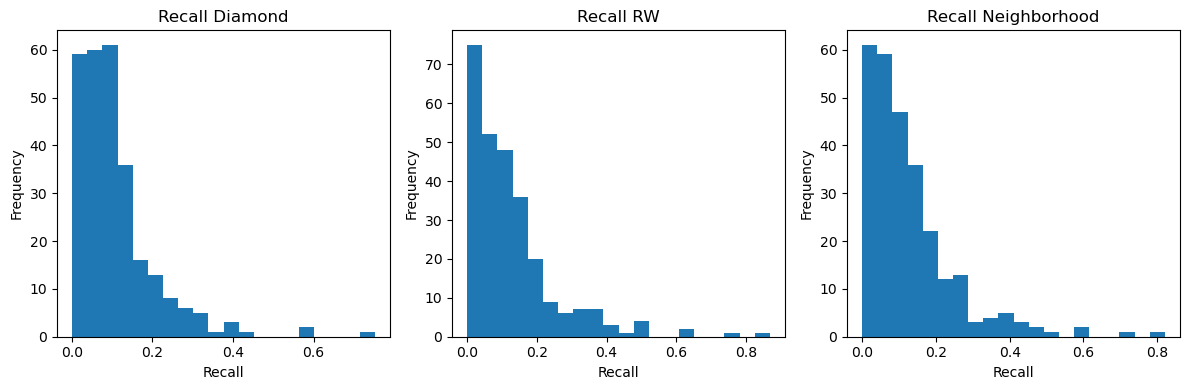

In [57]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
mean_results_df['recall_diamond'].hist(bins=20, ax=ax1)
mean_results_df['recall_rw'].hist(bins=20, ax=ax2)
mean_results_df['recall_neighborhood'].hist(bins=20, ax=ax3)
ax1.set_title('Recall Diamond')
ax2.set_title('Recall RW')
ax3.set_title('Recall Neighborhood')
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Recall')
    ax.set_ylabel('Frequency')
    ax.grid(False)
plt.tight_layout()
plt.show()

Chosen disease:  lymphoma EFO_0000574
Number of ground truth proteins:  296


  0%|          | 0/2500 [00:00<?, ?it/s]

100%|██████████| 2500/2500 [00:00<00:00, 7204.31it/s]
/tmp/ipykernel_3349993/2590625724.py:40: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  found_matrix[i,j] = found['count']


Number of proteins found:  98


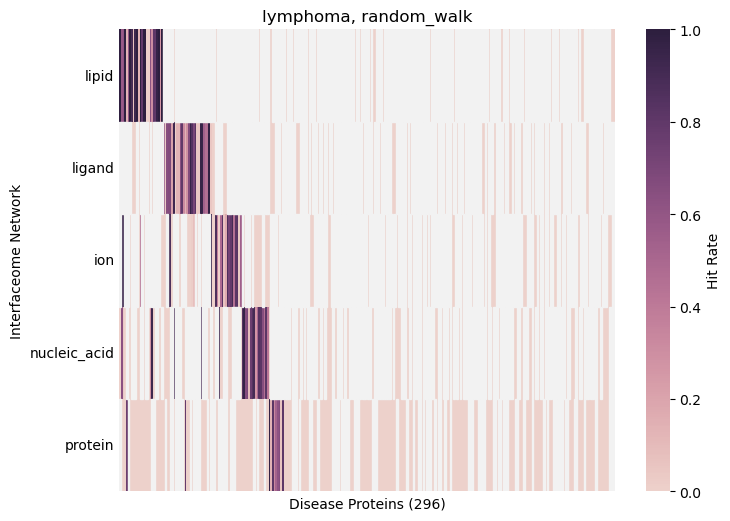

In [58]:
# chosen_disease_name = 'autoimmune neuropathy'
# chosen_disease_name = 'multiple sclerosis'
chosen_disease_name = 'lymphoma'

chosen_method = 'random_walk'
chosen_disease = disease_name_to_id[chosen_disease_name]
print("Chosen disease: ", chosen_disease_name, chosen_disease)

modalities = ['protein', 'lipid', 'nucleic_acid', 'ligand', 'ion']
gt_proteins = set(disease_associations[disease_associations['diseaseId'] == chosen_disease]['uniprot_targetId'].to_list())
print("Number of ground truth proteins: ", len(gt_proteins))

found_list = []
for _, row in tqdm(results_df[results_df['diseaseId'] == chosen_disease].iterrows(), total=len(results_df[results_df['diseaseId'] == chosen_disease])):
    if row['found_diamond'] is pd.NA:
        row['found_diamond'] = []
    if row['found_rw'] is pd.NA:
        row['found_rw'] = []
    if row['found_neighborhood'] is pd.NA:
        row['found_neighborhood'] = []
    for found_prot in set(row['found_diamond']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "diamond"})
    for found_prot in set(row['found_rw']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "random_walk"})
    for found_prot in set(row['found_neighborhood']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "neighborhood"})
found_df = pd.DataFrame(found_list)
found_df = found_df.groupby(['modality', 'model', 'found_prot']).size().reset_index(name='count')

print("Number of proteins found: ", len(found_df[found_df['model'] == chosen_method]['found_prot'].unique()))


found_matrix = np.zeros((len(modalities), len(gt_proteins)))

num_trials = results_df[results_df['diseaseId'] == chosen_disease][['modality', 'fold']].value_counts().mean()
for i, modality in enumerate(modalities):
    for j, protein in enumerate(gt_proteins):
        found = found_df[(found_df['modality'] == modality) & (found_df['model'] == chosen_method) & (found_df['found_prot'] == protein)]
        if len(found) > 0:
            found_matrix[i,j] = found['count']
        elif not protein in modality_graphs[modality]['uniprot_to_node_idx']:
            found_matrix[i,j] = -1
        else:
            protein_idx = modality_graphs[modality]['uniprot_to_node_idx'][protein]
            if protein_idx in modality_graphs[modality]['largest_component']:
                found_matrix[i,j] = 0
            else:
                found_matrix[i,j] = -1
found_matrix[found_matrix > 0] = found_matrix[found_matrix > 0] / num_trials
assert found_matrix.max() <= 1

protein_order = []
modality_order = (found_matrix >= 0).sum(axis=1).argsort()
for modality in modality_order: # order modalities by number of found proteins
    for prot in np.where(found_matrix[modality] > 0)[0]:
        if prot not in protein_order:
            protein_order.append(prot)
for i in range(found_matrix.shape[1]):
    if i not in protein_order:
        protein_order.append(i)
found_matrix = found_matrix[:,protein_order]
found_matrix = found_matrix[modality_order]

plt.figure(figsize=(8, 6))
mask = found_matrix==-1
ax = sns.heatmap(found_matrix, cmap=sns.cubehelix_palette(as_cmap=True), mask=mask, cbar_kws={"label": "Hit Rate"}, vmin=0, vmax=1)
for i, j in zip(*np.where(mask)):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fc='#F2F2F2', ec='#F2F2F2'))

plt.yticks(np.arange(len(modalities))+0.5, np.array(modalities)[modality_order], rotation=0)
if len(gt_proteins) < 50:
    plt.xticks(np.arange(len(gt_proteins))+0.5, np.array(list(gt_proteins))[protein_order], rotation=90)
else:
    ax.set_xticklabels([])
    ax.set_xticks([])
ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)
plt.title(f"{disease_id_to_name[chosen_disease]}, {chosen_method}")
plt.ylabel("Interfaceome Network")
plt.xlabel(f"Disease Proteins ({len(gt_proteins)})")
plt.show()
        

In [121]:
found_proteins_by_network = found_df[found_df.model == chosen_method].pivot_table(index='found_prot', columns='modality', values='count').fillna(0).reset_index()
found_proteins_by_network['gene'] = found_proteins_by_network['found_prot'].map(uniprot_to_gene)
found_proteins_by_network['protein_name'] = found_proteins_by_network['found_prot'].map(uniprot_to_protein_name)

found_proteins_by_network['evidence_score'] = found_proteins_by_network['found_prot'].map(lambda x: disease_associations[(disease_associations['uniprot_targetId'] == x) & (disease_associations['diseaseName'] == chosen_disease_name)]['score'].values[0])
found_proteins_by_network['evidence_count'] = found_proteins_by_network['found_prot'].map(lambda x: disease_associations[(disease_associations['uniprot_targetId'] == x) & (disease_associations['diseaseName'] == chosen_disease_name)]['evidenceCount'].values[0])

found_proteins_by_network.sort_values('lipid', ascending=False).head(50)

modality,found_prot,ion,ligand,lipid,nucleic_acid,protein,gene,protein_name,evidence_score,evidence_count
96,Q9UQD0,44.0,0.0,100.0,0.0,0.0,SCN8A MED,Sodium channel protein type 8 subunit alpha (S...,0.527616,5
97,Q9Y5Y9,0.0,0.0,100.0,0.0,0.0,SCN10A,Sodium channel protein type 10 subunit alpha (...,0.527616,5
85,Q99250,0.0,0.0,100.0,0.0,0.0,SCN2A HBA NAC2 SCN2A1 SCN2A2,Sodium channel protein type 2 subunit alpha (H...,0.527616,5
73,Q15858,0.0,0.0,99.0,0.0,0.0,SCN9A NENA,Sodium channel protein type 9 subunit alpha (N...,0.527616,5
41,P35499,0.0,0.0,99.0,0.0,0.0,SCN4A,Sodium channel protein type 4 subunit alpha (S...,0.527616,5
64,Q01118,0.0,0.0,99.0,0.0,0.0,SCN7A SCN6A,Sodium channel protein type 7 subunit alpha (A...,0.527616,5
91,Q9NY46,0.0,0.0,99.0,0.0,0.0,SCN3A KIAA1356 NAC3,Sodium channel protein type 3 subunit alpha (S...,0.527616,5
70,Q14524,0.0,0.0,99.0,0.0,0.0,SCN5A,Sodium channel protein type 5 subunit alpha (S...,0.528725,6
94,Q9UI33,0.0,0.0,99.0,0.0,0.0,SCN11A SCN12A SNS2,Sodium channel protein type 11 subunit alpha (...,0.527616,5
40,P35498,0.0,0.0,96.0,0.0,0.0,SCN1A NAC1 SCN1,Sodium channel protein type 1 subunit alpha (S...,0.527616,5


In [91]:
visualisation_df = found_df[found_df['model'] == chosen_method].copy()
visualisation_df['count'] /= num_trials
visualisation_df['gene'] = visualisation_df['found_prot'].map(uniprot_to_gene)

missing_rows = []
for protein in visualisation_df['found_prot'].unique():
    for modality in modalities:
        if not protein in set(visualisation_df[visualisation_df['modality'] == modality]['found_prot']):
            largest_component = modality_graphs[modality]['largest_component']
            uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
            if protein in uniprot_to_node_idx and uniprot_to_node_idx[protein] in largest_component:
                missing_rows.append({"modality": modality, "found_prot": protein, "count": 0, "gene": uniprot_to_gene.get(protein, "")})
            else:
                missing_rows.append({"modality": modality, "found_prot": protein, "count": -1, "gene": uniprot_to_gene.get(protein, "")})
missing_rows = pd.DataFrame(missing_rows)

visualisation_df = pd.concat([visualisation_df, missing_rows])
visualisation_df.to_csv(f"visualisation/{chosen_disease_name}_{chosen_method}.csv")

In [94]:
len(visualisation_df[visualisation_df['count'] == -1]["found_prot"].unique())

95